# **Exercise** **1**

In [1]:
# Import Libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Read and display the image

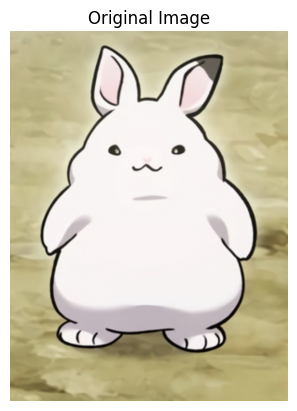

In [ ]:
# Load Image
img = Image.open("/content/drive/MyDrive/image.jpeg")   # replace with your image path

# Display using matplotlib
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

2. Display only the top left corner of 100x100 pixels.

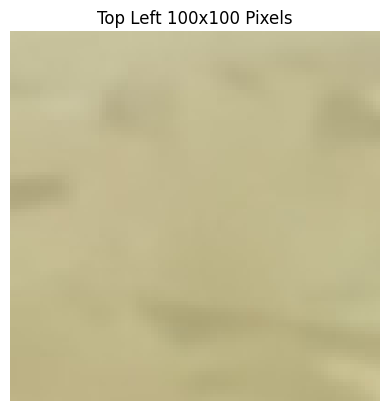

In [ ]:
# Convert image to numpy array
img_array = np.array(img)

# Extract top-left 100x100 region
top_left = img_array[0:100, 0:100]

# Display
plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

3. Show the three color channels (R, G, B).

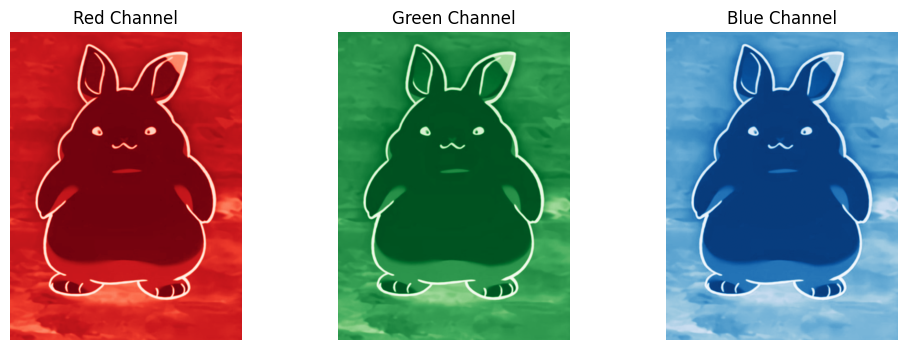

In [ ]:
# Separate channels
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

4. Modify the top 100 ×100 pixels to a value of 210 and display the resulting image:

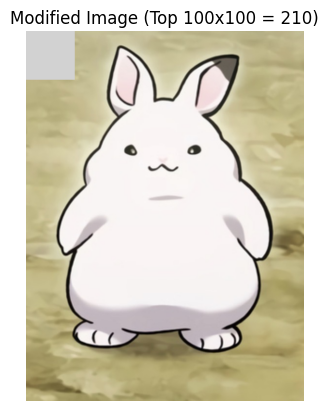

In [ ]:
# Modify region
modified = img_array.copy()
modified[0:100,0:100] = 210

# Display result
plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

# **Exercise 2**


1. Load and display a grayscale image

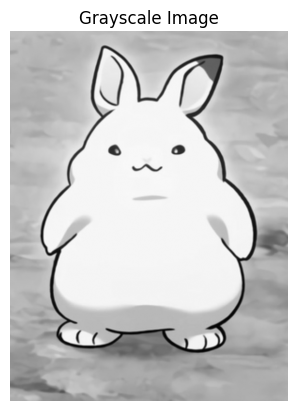

In [ ]:
# Load grayscale image
gray_img = Image.open("/content/drive/MyDrive/image.jpeg").convert("L")

plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2. Extract and display the middle section of the image

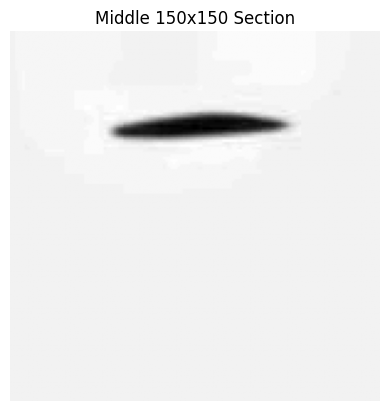

In [ ]:
gray_array = np.array(gray_img)

h, w = gray_array.shape

center_h = h//2
center_w = w//2

middle = gray_array[center_h-75:center_h+75, center_w-75:center_w+75]

plt.imshow(middle, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image

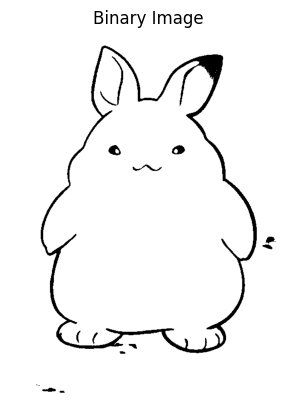

In [ ]:
binary = gray_array.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result

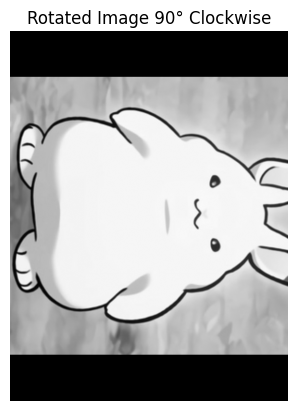

In [ ]:
rotated = gray_img.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image 90° Clockwise")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.

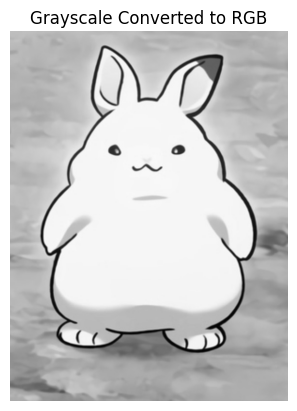

In [ ]:
rgb_img = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_img)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

# **Exericse 3**

1. Load and Prepare Data:

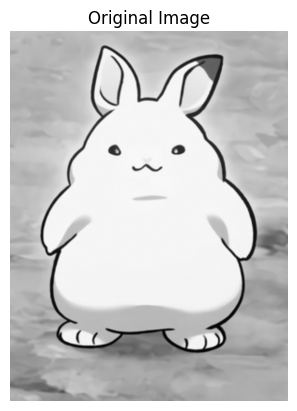

In [ ]:
# Load image and convert to grayscale
img = Image.open("/content/drive/MyDrive/image.jpeg").convert("L")

img_array = np.array(img)

plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# Standardize data
mean = np.mean(img_array, axis=0)
centered = img_array - mean

# Covariance matrix
cov_matrix = np.cov(centered, rowvar=False)

In [ ]:
mean = np.mean(img_array, axis=0)
centered_data = img_array - mean

In [ ]:
cov_matrix = np.cov(centered_data, rowvar=False)

2. Eigen Decomposition and Identifying Principal Components

In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

In [ ]:
sorted_index = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

In [ ]:
explained_variance = eigenvalues / np.sum(eigenvalues)

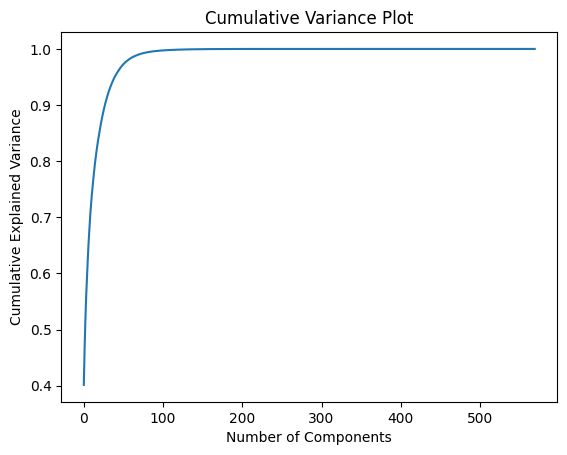

In [ ]:
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Plot")
plt.show()

3. Reconstruction and Experiment

In [ ]:
def reconstruct_image(k):

    eigenvector_subset = eigenvectors[:, :k]

    reduced_data = np.dot(centered_data, eigenvector_subset)

    reconstructed = np.dot(reduced_data, eigenvector_subset.T) + mean

    return reconstructed

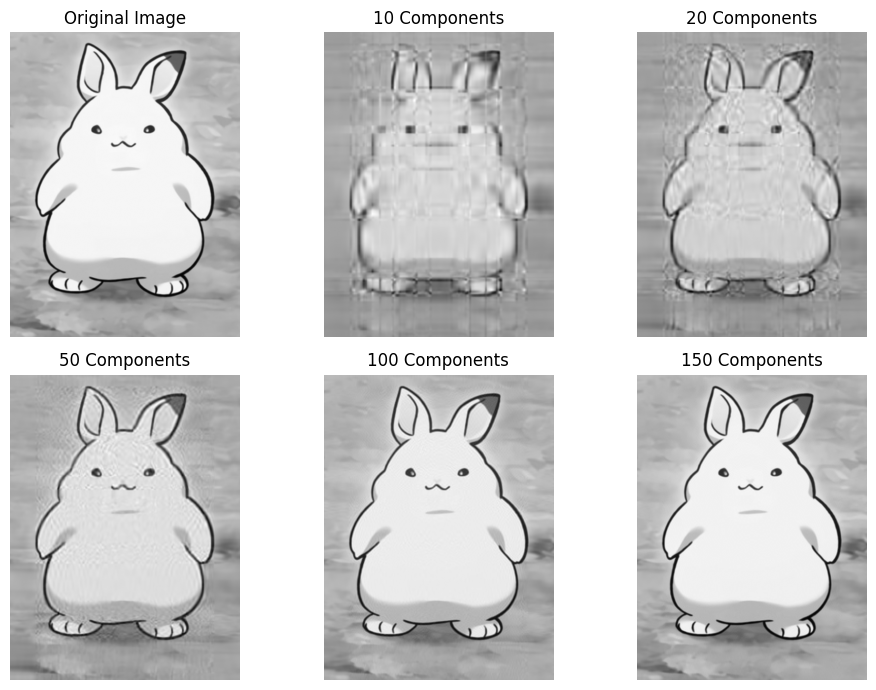

In [ ]:
components = [10, 20, 50, 100, 150]

plt.figure(figsize=(10,7))

plt.subplot(2,3,1)
plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis("off")

for i, k in enumerate(components):

    reconstructed_img = reconstruct_image(k)

    plt.subplot(2,3,i+2)
    plt.imshow(reconstructed_img, cmap='gray')
    plt.title(f"{k} Components")
    plt.axis("off")

plt.tight_layout()
plt.show()